In [1]:
import torch
import pandas as pd
from go_ml.train_utils import get_enzyme_df, enzyme_iterator
import pickle

enzyme_df = get_enzyme_df()

import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')

/home/andrew/anaconda3/envs/gointerp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from go_ml.data_utils import ProtDataset, get_seq_collator
enzyme_ds = ProtDataset(list(enzyme_df['UniprotID']), list(enzyme_df['Sequence']))

In [3]:
from torch.utils.data import DataLoader
collate_seqs = get_seq_collator(tokenizer, max_length=1024, add_special_tokens=True)
enzyme_dl = DataLoader(enzyme_ds, shuffle=False, batch_size=60, collate_fn=collate_seqs)

In [9]:
print(next(iter(enzyme_dl)).keys())

dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])


In [4]:
from go_ml.models.bert_finetune import BERTFinetune
device = torch.device('cuda:0')
checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
model.eval()

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTFinetune(
  (model): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 1280, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embeddings): Embedding(1026, 1280, padding_idx=1)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-32): 33 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=1280, out_features=1280, bias=True)
              (key): Linear(in_features=1280, out_features=1280, bias=True)
              (value): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((1280,), eps=1e-05, 

In [5]:
print(len(enzyme_dl))

14


In [10]:
def get_evals(model, seq_dl):
    device = model.device
    eval_l = []
    with torch.no_grad():
        for i, batch in enumerate(seq_dl):
            seq_ind, mask =  batch['seq_ind'].to(device), torch.BoolTensor(batch['mask']).to(device)
            logit_preds = model.forward(seq_ind, mask).cpu()
            eval_l.append(logit_preds)
            if(i % (12*seq_dl.batch_size) == 0 and i > 0):
                print(f"{100*i/len()}% Eval")
    eval_results = torch.cat(eval_l, dim=0)
    return eval_results
enzyme_evals = get_evals(model, enzyme_dl)

dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])
dict_keys(['prot_id', 'seq', 'seq_ind', 'mask'])


In [14]:
enzyme_df

,UniprotID,AnnotatedIndices,EnzymeClass,GOTerm,Sequence,GOTermIndex
1,A0QTN8,"[162, 191, 217, 242, 266, 294]",5.5.1.1,GO:0018849,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...,12611
2,A2RJT9,"[43, 130]",1.3.98.1,GO:1990663,MLNTTFANAKFANPFMNASGVHCMTIEDLEELKASQAGAYITKSST...,6256
3,A4XF23,"[147, 159, 210, 212, 236, 262, 283, 339]",4.2.1.8,GO:0008927,MKITAARVIITCPGRNFVTLKIETDQGVYGIGDATLNGRELSVVAY...,1500
4,A5JTM5,"[64, 86, 90, 114, 137, 145]",3.8.1.7,GO:0018787,MYEAIGHRVEDGVAEITIKLPRHRNALSVKAMQEVTDALNRAEEDD...,19157
5,A5JUY8,"[105, 108, 110, 184, 186, 188, 190, 258, 351]",1.11.1.7,GO:0140825,MWVCLQLPVFLASVTLFEVAASDTIAQAASTTTISDAVSKVKIQVN...,2030
...,...,...,...,...,...,...
842,Q9YHT1,"[130, 251, 253, 263, 266, 297, 364, 408]",1.3.5.1,GO:0008177,MAAVVAASRSLAKCWLRPAVRAWPAACQTHARNFHFTVDGKKNAST...,3811
843,Q9ZAG3,"[53, 55, 99, 101, 132]",3.3.2.8,GO:0018744,MTSKIEQPRWASKDSAAGAASTPDEKIVLEFMDALTSNDAAKLIEY...,26152
844,Q9ZF13,"[50, 127, 128, 196, 198, 225, 254]",3.2.1.78,GO:0016985,GLHVKNGRLYEANGQEFIIRGVSHPHNWYPQHTQAFADIKSHGANT...,4352
845,Q9ZHI0,"[114, 116, 118, 221, 312, 406, 409, 422, 427]",6.5.1.2,GO:0003911,MTREEARRRINELRDLIRYHNYRYYVLADPEISDAEYDRLLRELKE...,389


In [30]:
enzyme_go_ind = list(enzyme_df['GOTermIndex'])
te = enzyme_evals[torch.arange(enzyme_evals.shape[0]), enzyme_go_ind]
re = enzyme_evals[torch.arange(enzyme_evals.shape[0]), torch.randint(0, max(enzyme_go_ind), (enzyme_evals.shape[0],))]

In [32]:
print(te.mean(), enzyme_evals.mean())

tensor(-4.9111) tensor(-13.0491)


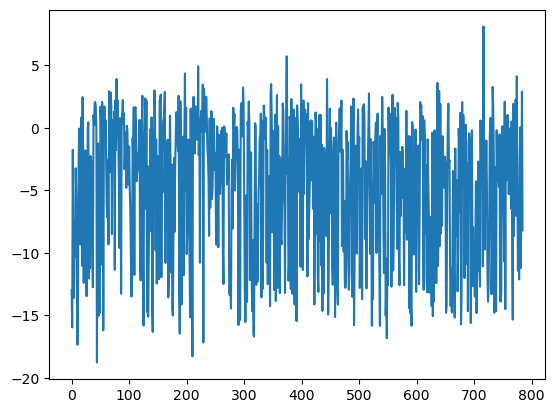

In [26]:
import matplotlib.pyplot as plt
plt.plot(te.numpy().flatten())
plt.show()

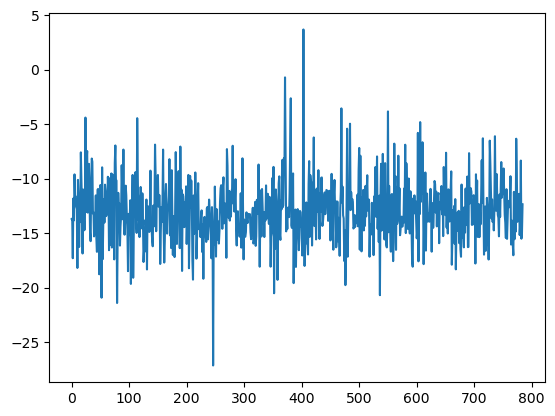

In [31]:
plt.plot(re.numpy().flatten())
plt.show()

In [13]:
print(enzyme_evals.shape)

torch.Size([785, 29185])
